### Text Preprocessing

The objective of this notebook is to clean the textual documents before training the model again.

The baseline model achieved an accuracy of 86% using the original text. In this notebook, text preprocessing techniques are applied to investigate whether cleaning the text improves the classification performance.

In [40]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
pd.set_option("display.max_colwidth", None)

In [41]:
df = pd.read_csv('data.csv')

In [42]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\amand\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [43]:
english_stopwords = set(stopwords.words('english'))

print(f"Total English Stopwords : {len(english_stopwords)}")

Total English Stopwords : 198


In [44]:
df.sample(2)

,Document,Topic_group,text_length
29402,address change pm change importance high hi starter today has normally fine occasionally cause problems sites because apostrophe therefore changed apostrophe created without apostrophe both routed easier change existing fine going forward thanks,Miscellaneous,33
33621,allocation purchase request for it final owner maxim id has been approved friday july pm purchase final owner id has approved hi purchased gen scanning device added tag also details added please log proper installation thank administrator ext wednesday pm purchase final owner id has approved dear pleased inform purchase has approved notified further progress due thank puma user guide found purchase note mailbox receive messages note mailbox receive messages,Purchase,70


In [45]:
custom_stopwords = {

    # Greetings
    "dear",
    "hello",
    "hi",

    # Politeness
    "please",
    "thanks",
    "thank",
    "regards",
    "regard",
    "kind",
    "kindly",
    "best",

    # Time
    "monday",
    "tuesday",
    "wednesday",
    "thursday",
    "friday",

    "january",
    "february",
    "march",
    "april",
    "may",
    "june",
    "july",
    "august",
    "september",
    "october",
    "november",
    "december",

    # Email metadata
    "pm",
    "am",
    "sent",
    "attached",
    "attachment",
    "forwarded",
    "ext",

    # Generic words
    "let",
    "good",
    "morning",
    "afternoon",
    "evening",
    "could",
    "also"
}

In [46]:
# custom_stopwords = {
#     "dear",
#     "thanks",
#     "thank",
#     "regards",
#     "kind",
#     "hello",
#     "hi",
#     "please",
#     "good",
#     "morning",
#     "afternoon",
#     "evening"
# }

In [47]:
all_stopwords = english_stopwords.union(custom_stopwords)

### Text Cleaning Function

A preprocessing function is created to clean each document before feature extraction.

The following preprocessing steps are performed:

1. Convert text to lowercase.
2. Remove numbers.
3. Remove punctuation and special characters.
4. Remove extra whitespaces.
5. Remove English stopwords.
6. Remove custom stopwords identified during EDA.

In [48]:
def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    words = text.split()

    # Remove stopwords
    words = [
        word
        for word in words
        if word not in all_stopwords
    ]

    # Join words back into a sentence
    return " ".join(words)

In [49]:
df["Clean_Document"] = df["Document"].apply(preprocess_text)

In [50]:
from collections import Counter

all_words = " ".join(df["Clean_Document"]).split()

word_counts = Counter(all_words)

word_counts.most_common(50)

[('access', 13153),
 ('help', 11173),
 ('error', 9291),
 ('issue', 8802),
 ('change', 7816),
 ('engineer', 7545),
 ('log', 7280),
 ('add', 7231),
 ('date', 6558),
 ('information', 6500),
 ('form', 6303),
 ('new', 6271),
 ('senior', 6207),
 ('details', 6129),
 ('leaver', 6096),
 ('name', 6005),
 ('code', 5629),
 ('update', 5601),
 ('order', 5433),
 ('issues', 5374),
 ('analyst', 5305),
 ('leave', 5288),
 ('report', 5149),
 ('card', 5115),
 ('site', 5053),
 ('number', 4946),
 ('create', 4903),
 ('client', 4871),
 ('starter', 4816),
 ('confluence', 4775),
 ('provide', 4758),
 ('work', 4747),
 ('officer', 4700),
 ('cannot', 4643),
 ('working', 4561),
 ('manager', 4451),
 ('high', 4439),
 ('po', 4358),
 ('purchase', 4349),
 ('user', 4321),
 ('request', 4287),
 ('days', 4222),
 ('si', 4105),
 ('needed', 4085),
 ('oracle', 3997),
 ('location', 3981),
 ('find', 3949),
 ('problem', 3901),
 ('administrator', 3869),
 ('assigned', 3866)]

In [51]:
for i in range(5):
    print("=" * 100)
    print("Original Document:\n")
    print(df["Document"].iloc[i])

    print("\nCleaned Document:\n")
    print(df["Clean_Document"].iloc[i])
    print()

Original Document:

connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead

Cleaned Document:

connection icon icon setup icon per icon engineers details needed lead

Original Document:

work experience user work experience user hi work experience student coming next his name much appreciate him duration thank

Cleaned Document:

work experience user work experience user work experience student coming next name much appreciate duration

Original Document:

requesting for meeting requesting meeting hi please help follow equipments cable pc cord plug

Cleaned Document:

requesting meeting requesting meeting help follow equipments cable pc cord plug

Original Document:

reset passwords for external accounts re expire days hi ask help update passwords colleagues thank pm expire days importance high hi received about expiration please kindly help prolongation best regards pm expire days importance high dear expire days order change pl

In [52]:
df.head(2)

,Document,Topic_group,text_length,Clean_Document
0,connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead,Hardware,18,connection icon icon setup icon per icon engineers details needed lead
1,work experience user work experience user hi work experience student coming next his name much appreciate him duration thank,Access,19,work experience user work experience user work experience student coming next name much appreciate duration


In [53]:
X = df['Clean_Document']
y = df['Topic_group']

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [55]:
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [56]:
print("Vocabulary Size:", len(tfidf.vocabulary_))

Vocabulary Size: 11504


In [57]:
model = LogisticRegression(random_state = 42, max_iter = 1000)
model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [58]:
y_pred = model.predict(X_test_tfidf)
y_pred

array(['Internal Project', 'HR Support', 'Miscellaneous', ...,
       'HR Support', 'Hardware', 'Storage'], shape=(9568,), dtype=object)

In [59]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.8508


In [60]:
print(classification_report(y_test, y_pred))

                       precision    recall  f1-score   support

               Access       0.92      0.87      0.89      1425
Administrative rights       0.88      0.64      0.74       352
           HR Support       0.86      0.84      0.85      2183
             Hardware       0.78      0.89      0.83      2724
     Internal Project       0.91      0.81      0.86       424
        Miscellaneous       0.83      0.83      0.83      1412
             Purchase       0.98      0.86      0.92       493
              Storage       0.94      0.86      0.90       555

             accuracy                           0.85      9568
            macro avg       0.89      0.83      0.85      9568
         weighted avg       0.86      0.85      0.85      9568



In [61]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1241    3   36   99    3   38    1    4]
 [   5  226   10  101    0    8    2    0]
 [  35    4 1833  224   10   70    1    6]
 [  54   18  125 2425    9   82    4    7]
 [   2    0   35   27  342   18    0    0]
 [  14    2   71  132   10 1171    2   10]
 [   1    2    7   45    1    9  426    2]
 [   1    2   21   41    0   14    0  476]]


<Figure size 1000x800 with 0 Axes>

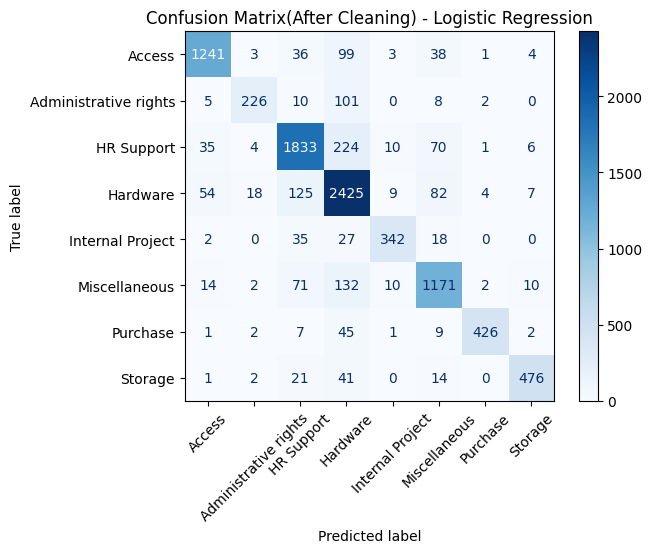

In [62]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

plt.figure(figsize=(10,8))

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix(After Cleaning) - Logistic Regression")
plt.show()